# Churn Risk-Adjusted Customer Value in Retail Banking

## Implementation

This notebook contains the implementation of the churn risk-adjusted Customer Value framework, including data preparation, baseline Customer Value estimation, churn prediction modelling, model evaluation and integration of predicted churn risk with Customer Value.

In [2]:
# Loading packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [4]:
# 6a: Data Loading and Initial Inspection

# Loading data
data_path = Path("../data/Bank Customer Churn Prediction.csv")
df = pd.read_csv(data_path)

# Inspecting the data

In [10]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df.shape

(10000, 12)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [13]:
df.columns.tolist()

['customer_id',
 'credit_score',
 'country',
 'gender',
 'age',
 'tenure',
 'balance',
 'products_number',
 'credit_card',
 'active_member',
 'estimated_salary',
 'churn']

In [14]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["churn"].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

In [17]:
df["churn"].value_counts(normalize=True)

churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [18]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [20]:
# Unique values in categorical/binary variables
for col in ["country", "gender", "credit_card", "active_member", "products_number", "churn"]:
    print(f"\n{col}")
    print(df[col].value_counts())


country
country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

gender
gender
Male      5457
Female    4543
Name: count, dtype: int64

credit_card
credit_card
1    7055
0    2945
Name: count, dtype: int64

active_member
active_member
1    5151
0    4849
Name: count, dtype: int64

products_number
products_number
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

churn
churn
0    7963
1    2037
Name: count, dtype: int64


In [22]:
df["products_number"].value_counts().sort_index()

products_number
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [21]:
zero_balance = (df["balance"] == 0).sum()

print("Customers with zero balance:", zero_balance)
print("Percentage with zero balance:", zero_balance / len(df) * 100)

Customers with zero balance: 3617
Percentage with zero balance: 36.17


In [23]:
pd.crosstab(
    df["products_number"],
    df["balance"] == 0,
    margins=True
)

balance,False,True,All
products_number,,,
1,4179,905,5084
2,1990,2600,4590
3,168,98,266
4,46,14,60
All,6383,3617,10000


### Key  notes from the initial inspection findings

The dataset contains 10K customers and 12 variables

-No missing values.

-No duplicate customer records.

-The churn variable is imbalanced, with 7,963 (79.63%) non-churners and 2,037 (20.37%) churners.

-3,617 customers (36.17%) have a zero account balance.

-Product ownership ranges from 1-4. Most customers hold either one (5,084) or two (4,590) products.

-of the zero balance customers, 2,600 hold two products, while 112 customers hold three or four products.

The design of the baseline Customer Value measure will need to be modified due to high number of zero balance customers. A purely multiplicative combination of balance and product ownership would assign a CV score of zero to all zero-balance customers regardless of their product holdings. Therefore, the method used to combine balance and product ownership will be investigated further before the final CV calculation is implemented.

## 6.2 Exploratory Data Analysis

### 6.2.1 Churn Distribution

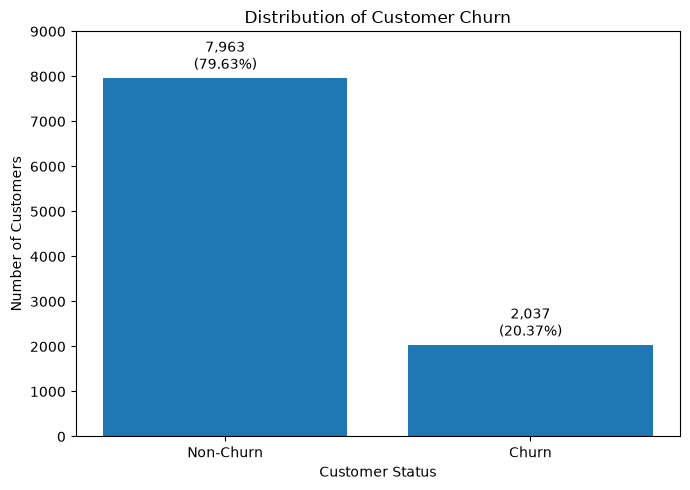

In [26]:
# Churn distribution
churn_counts = df["churn"].value_counts().sort_index()
churn_percentages = df["churn"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["Non-Churn", "Churn"],
    churn_counts.values
)

ax.set_title("Distribution of Customer Churn")
ax.set_xlabel("Customer Status")
ax.set_ylabel("Number of Customers")

# Add count and percentage labels
for bar, count, percentage in zip(
    bars,
    churn_counts.values,
    churn_percentages.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

# Add extra space above bars
ax.set_ylim(0, 9000)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Churn Distribution Findings

The dataset contains 7,963 non-churners (79.63%) and 2,037 churners (20.37%), showing a clear imbalance towards the non-churn class. Although the minority churn class remains sufficiently represented for modelling, the imbalance could cause classifiers to favour the majority class. Therefore, model performance will be assessed using metrics including precision, recall, F1-score and ROC-AUC rather than relying on accuracy alone. The effect of class-imbalance treatments will also be investigated during model development.

### 6.2.2 Numerical Variables and Churn

Numerical customer characteristics were compared between churners and non-churners to identify variables that may show an association with customer attrition. Mean and median values were examined for the main continuous and ordinal variables.

In [27]:
# Numerical variables to examine
numerical_vars = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "estimated_salary"
]

# Compare mean and median values by churn status
numerical_churn_summary = (
    df.groupby("churn")[numerical_vars]
      .agg(["mean", "median"])
      .round(2)
)

numerical_churn_summary

credit_score           age        tenure          balance             \
              mean median   mean median   mean median      mean     median   
churn                                                                        
0           651.85  653.0  37.41   36.0   5.03    5.0  72745.30   92072.68   
1           645.35  646.0  44.84   45.0   4.93    5.0  91108.54  109349.29   

      products_number        estimated_salary             
                 mean median             mean     median  
churn                                                     
0                1.54    2.0         99738.39   99645.04  
1                1.48    1.0        101465.68  102460.84

In [28]:
# Churn rate by number of products
product_churn = (
    df.groupby("products_number")["churn"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "customers",
          "sum": "churners",
          "mean": "churn_rate"
      })
)

product_churn["churn_rate"] = (
    product_churn["churn_rate"] * 100
).round(2)

product_churn

,customers,churners,churn_rate
products_number,,,
1,5084,1409,27.71
2,4590,348,7.58
3,266,220,82.71
4,60,60,100.00


#### Numerical Variable Findings

Initial comparison between churners and non-churners shows that age and account balance display the clearest differences. Churners were older on average (44.84 years compared with 37.41 years for non-churners) and held a higher average account balance (91,108.54 compared with 72,745.30). In comparison, credit score, tenure and estimated salary showed relatively small differences between the two groups.

Product ownership showed a notable non-linear relationship with churn. Customers holding two products had the lowest observed churn rate (7.58%), compared with 27.71% among customers holding one product. Churn rates increased substantially among customers holding three (82.71%) and four (100%) products. However, the three and four product groups contain considerably fewer customers, with only 266 and 60 observations respectively, and these high churn rates should therefore be interpreted cautiously.

These findings suggest that examining mean values alone may hide important relationships between customer characteristics and churn. Further visual analysis will therefore be used to examine the distributions of age, balance and product ownership.

### 6.2.3 Age and Churn

Age showed one of the clearest differences between churners and non-churners during the initial numerical comparison. The distribution of age was therefore examined in greater detail to determine how churn varies across different age groups.

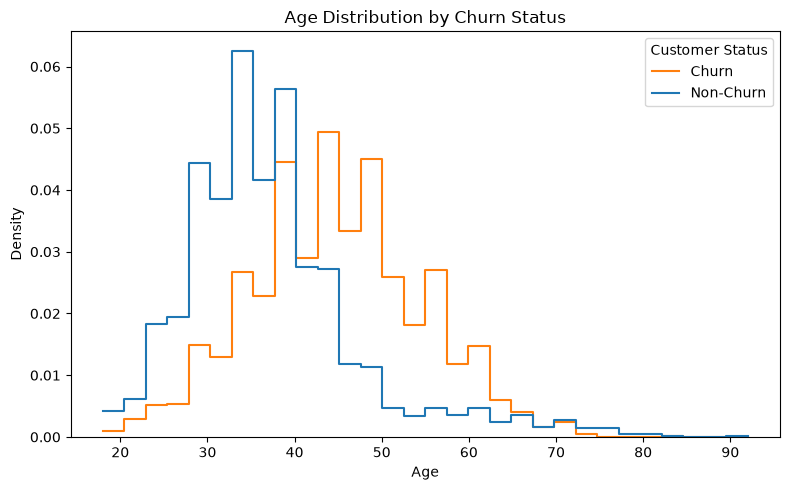

In [5]:
# Compare age distribution by churn status
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    hue="churn",
    bins=30,
    stat="density",
    common_norm=False,
    element="step",
    fill=False
)

plt.title("Age Distribution by Churn Status")
plt.xlabel("Age")
plt.ylabel("Density")

plt.legend(
    title="Customer Status",
    labels=["Churn", "Non-Churn"]
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/age_distribution_by_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
# Create age groups for exploratory analysis
age_bins = [18, 30, 40, 50, 60, 70, 100]
age_labels = [
    "18-29",
    "30-39",
    "40-49",
    "50-59",
    "60-69",
    "70+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

age_churn = (
    df.groupby("age_group", observed=False)["churn"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "customers",
          "sum": "churners",
          "mean": "churn_rate"
      })
)

age_churn["churn_rate"] = (
    age_churn["churn_rate"] * 100
).round(2)

age_churn

,customers,churners,churn_rate
age_group,,,
18-29,1641,124,7.56
30-39,4346,473,10.88
40-49,2618,806,30.79
50-59,869,487,56.04
60-69,375,132,35.20
70+,151,15,9.93


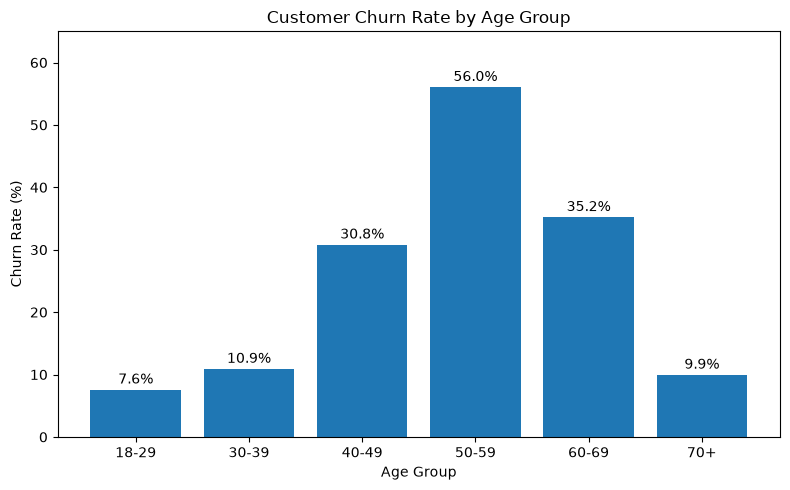

In [7]:
# Churn rate by age group
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    age_churn.index.astype(str),
    age_churn["churn_rate"]
)

ax.set_title("Customer Churn Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Churn Rate (%)")

for bar, rate in zip(bars, age_churn["churn_rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{rate:.1f}%",
        ha="center"
    )

ax.set_ylim(0, 65)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/churn_rate_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Age and Churn Findings

Age shows a clear non-linear relationship with customer churn. Churn rates increase from 7.56% among customers aged 18–29 and 10.88% among those aged 30–39 to 30.79% for customers aged 40–49. The highest observed churn rate occurs among customers aged 50–59, at 56.04%, before declining to 35.20% for customers aged 60–69 and 9.93% among those aged 70 and above.

The age distributions also show that churners are concentrated at older ages than non-churners, consistent with the earlier finding that churners have a higher mean age. However, the decline in churn among the oldest groups demonstrates that the relationship is not simply linear. The 70+ group also contains only 151 customers, so its observed churn rate should be interpreted cautiously.

### 6.2.4 Account Balance and Churn

Account balance is an important variable within the proposed framework because it contributes to the baseline Customer Value measure while also representing a potential predictor of churn. Initial inspection identified a substantial number of customers with zero balances. The relationship between account balance and churn was therefore examined by distinguishing between zero-balance and positive-balance customers before analysing the distribution of positive balances.

In [8]:
# Create zero-balance indicator for exploratory analysis
df["zero_balance"] = df["balance"] == 0

balance_status_churn = (
    df.groupby("zero_balance")["churn"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "customers",
          "sum": "churners",
          "mean": "churn_rate"
      })
)

balance_status_churn["churn_rate"] = (
    balance_status_churn["churn_rate"] * 100
).round(2)

balance_status_churn.index = ["Positive Balance", "Zero Balance"]

balance_status_churn

,customers,churners,churn_rate
Positive Balance,6383,1537,24.08
Zero Balance,3617,500,13.82


In [9]:
# Positive-balance customers only
positive_balance = df[df["balance"] > 0]

positive_balance_summary = (
    positive_balance.groupby("churn")["balance"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

positive_balance_summary

,count,mean,median,std
churn,,,,
0,4846,119535.86,119791.22,29944.93
1,1537,120746.97,119948.09,30555.19


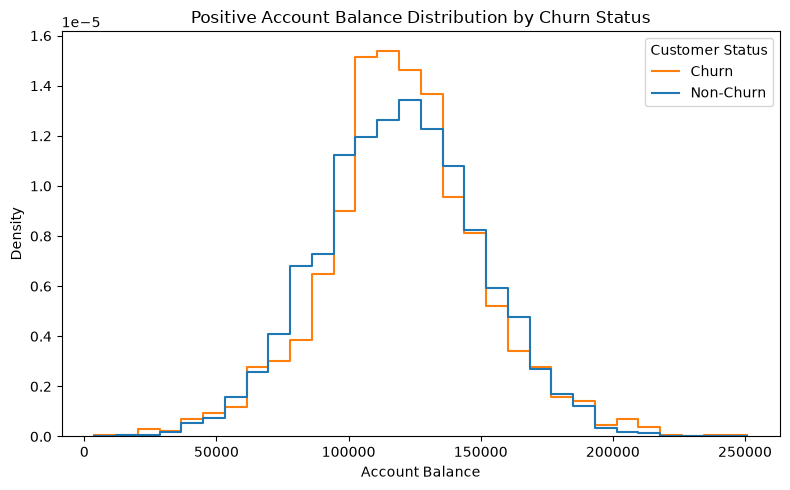

In [10]:
# Positive account balance distribution by churn status
plt.figure(figsize=(8, 5))

sns.histplot(
    data=positive_balance,
    x="balance",
    hue="churn",
    bins=30,
    stat="density",
    common_norm=False,
    element="step",
    fill=False
)

plt.title("Positive Account Balance Distribution by Churn Status")
plt.xlabel("Account Balance")
plt.ylabel("Density")

plt.legend(
    title="Customer Status",
    labels=["Churn", "Non-Churn"]
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/positive_balance_distribution_by_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Key findings

Customers with a positive account balance had a substantially higher churn rate (24.08%) than customers with a zero balance (13.82%). However, among customers with positive balances, the balance distributions of churners and non-churners were very similar. Churners had a mean balance of approximately 120,747 compared with 119,536 for non-churners, while the median balances were almost identical at approximately 119,948 and 119,791 respectively.

This indicates that the large difference in overall mean balance previously observed between churners and non-churners is influenced considerably by the presence of zero-balance customers, rather than by churners consistently holding much larger positive balances. Therefore, the relationship between balance and churn appears to be associated more strongly with whether a customer holds a positive balance than with the magnitude of the balance itself.

### 6.2.5 Product Ownership and Churn

Product ownership is one of the two financial variables proposed for the baseline Customer Value calculation. Its relationship with churn is therefore examined before constructing the baseline CV measure.

In [11]:
# Churn rate by number of products
product_churn = (
    df.groupby("products_number")["churn"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "customers",
          "sum": "churners",
          "mean": "churn_rate"
      })
)

product_churn["churn_rate"] = product_churn["churn_rate"] * 100

product_churn

,customers,churners,churn_rate
products_number,,,
1,5084,1409,27.714398
2,4590,348,7.581699
3,266,220,82.706767
4,60,60,100.000000


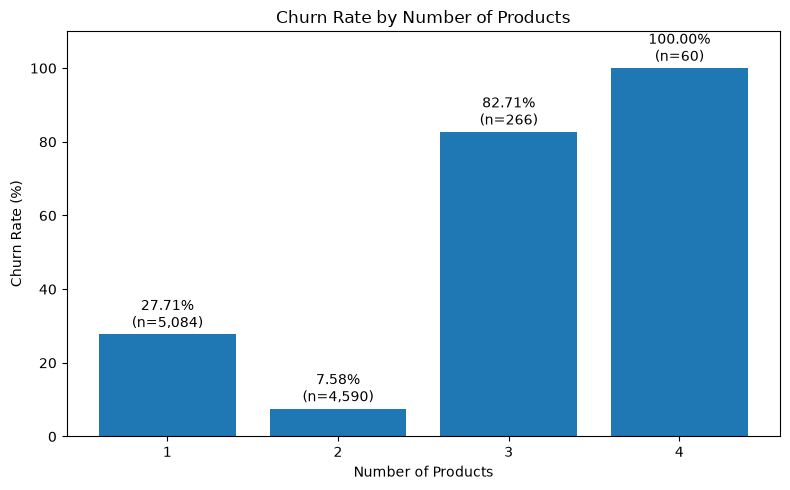

In [12]:
# Plot churn rate by number of products
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    product_churn.index.astype(str),
    product_churn["churn_rate"]
)

ax.set_title("Churn Rate by Number of Products")
ax.set_xlabel("Number of Products")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 110)

# Add churn rate and group size to each bar
for bar, (_, row) in zip(bars, product_churn.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f'{row["churn_rate"]:.2f}%\n(n={int(row["customers"]):,})',
        ha="center"
    )

plt.tight_layout()
plt.show()

In [13]:
# Customer characteristics by number of products
product_profile = (
    df.groupby("products_number")
      .agg(
          customers=("customer_id", "count"),
          churn_rate=("churn", "mean"),
          mean_age=("age", "mean"),
          mean_balance=("balance", "mean"),
          median_balance=("balance", "median"),
          active_rate=("active_member", "mean"),
          credit_card_rate=("credit_card", "mean"),
          mean_tenure=("tenure", "mean")
      )
)

product_profile["churn_rate"] *= 100
product_profile["active_rate"] *= 100
product_profile["credit_card_rate"] *= 100

product_profile.round(2)

,customers,churn_rate,mean_age,mean_balance,median_balance,active_rate,credit_card_rate,mean_tenure
products_number,,,,,,,,
1,5084,27.71,39.67,98551.87,111886.04,50.41,70.38,4.97
2,4590,7.58,37.75,51879.15,0.00,53.29,70.72,5.05
3,266,82.71,43.20,75458.33,95973.94,42.48,71.43,5.00
4,60,100.00,45.68,93733.14,116808.20,48.33,68.33,5.30


#### Key findings

Product ownership shows a strong non-linear relationship with customer churn. Customers holding two products had the lowest churn rate at 7.58%, compared with 27.71% among customers holding one product. Churn increased substantially among customers with three products, reaching 82.71%, while all 60 customers holding four products had churned.

The three and four product groups are considerably smaller than the one and two product groups, so the extreme churn rates should be interpreted with caution. Customers with three or four products were also older on average and had somewhat lower active membership rates, although average tenure and credit-card ownership were relatively similar across the product groups.

Balance also varied considerably by product ownership. In particular, customers holding two products had a median balance of zero despite having the lowest churn rate. Overall, the results indicate that the relationship between product ownership and churn is not linear, and that greater product ownership should not automatically be interpreted as indicating greater customer retention.

### 6.2.6 Active Membership and Churn

Active membership represents a behavioural characteristic of the customer relationship and is therefore examined as a potential predictor of churn.

In [14]:
# Churn by active membership status
active_churn = (
    df.groupby("active_member")["churn"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "customers",
          "sum": "churners",
          "mean": "churn_rate"
      })
)

active_churn["churn_rate"] = active_churn["churn_rate"] * 100

# Rename categories for readability
active_churn.index = active_churn.index.map({
    0: "Inactive",
    1: "Active"
})

active_churn.round(2)

,customers,churners,churn_rate
active_member,,,
Inactive,4849,1302,26.85
Active,5151,735,14.27


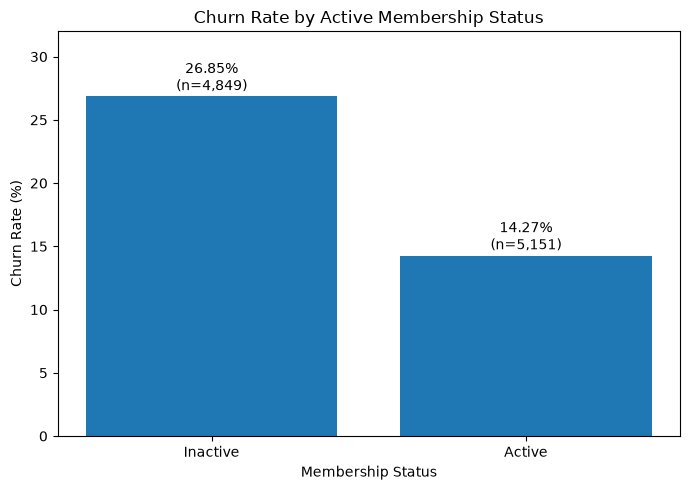

In [17]:
# Plot churn rate by active membership
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    active_churn.index,
    active_churn["churn_rate"]
)

ax.set_title("Churn Rate by Active Membership Status")
ax.set_xlabel("Membership Status")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 32)

# Add churn rate and group size above each bar
for bar, (_, row) in zip(bars, active_churn.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{row["churn_rate"]:.2f}%\n(n={int(row["customers"]):,})',
        ha="center"
    )

plt.tight_layout()
plt.show()

In [16]:
# Churn rate by age group and active membership
age_active_churn = (
    df.groupby(["age_group", "active_member"], observed=True)["churn"]
      .agg(["count", "mean"])
      .rename(columns={
          "count": "customers",
          "mean": "churn_rate"
      })
)

age_active_churn["churn_rate"] *= 100

age_active_churn.round(2)

customers  churn_rate
age_group active_member                       
18-29     0                    804        9.83
          1                    837        5.38
30-39     0                   2165       13.63
          1                   2181        8.16
40-49     0                   1396       37.97
          1                   1222       22.59
50-59     0                    373       81.23
          1                    496       37.10
60-69     0                     94       91.49
          1                    281       16.37
70+       0                     17       52.94
          1                    134        4.48

#### Key findings

Active membership shows a clear relationship with customer churn. Inactive customers had a churn rate of 26.85%, compared with 14.27% among active customers.

The difference remained when customers were compared within age groups, with active customers consistently showing lower churn rates. The difference was particularly pronounced among older customers. For example, among customers aged 50–59, the churn rate was 81.23% for inactive customers compared with 37.10% for active customers. Among customers aged 60–69, the corresponding rates were 91.49% and 16.37%.

These results suggest that active membership may provide useful information for churn prediction and that its relationship with churn may also vary with customer age. However, the results are descriptive and do not establish that active membership itself causes lower churn.

### 6.2.7 Country and Gender

Country and gender are examined to determine whether churn rates differ across the demographic groups represented within the dataset.

In [18]:
# Churn by country
country_churn = (
    df.groupby("country")["churn"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "customers",
          "sum": "churners",
          "mean": "churn_rate"
      })
)

country_churn["churn_rate"] *= 100
country_churn.round(2)

,customers,churners,churn_rate
country,,,
France,5014,810,16.15
Germany,2509,814,32.44
Spain,2477,413,16.67


In [19]:
# Churn by gender
gender_churn = (
    df.groupby("gender")["churn"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "customers",
          "sum": "churners",
          "mean": "churn_rate"
      })
)

gender_churn["churn_rate"] *= 100
gender_churn.round(2)

,customers,churners,churn_rate
gender,,,
Female,4543,1139,25.07
Male,5457,898,16.46


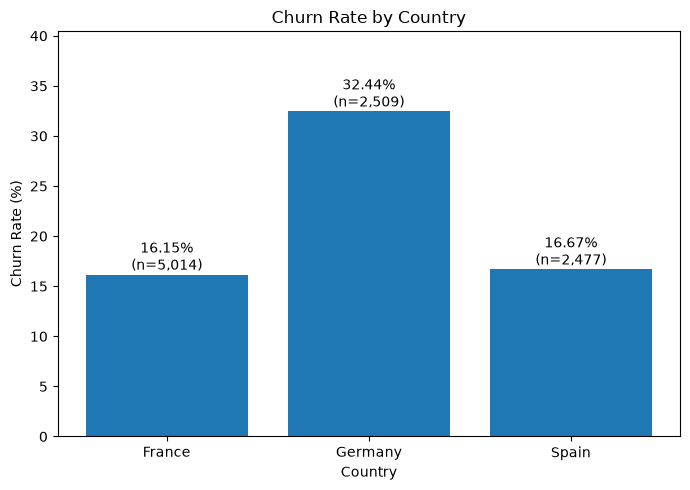

In [20]:
# Plot churn rate by country
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    country_churn.index,
    country_churn["churn_rate"]
)

ax.set_title("Churn Rate by Country")
ax.set_xlabel("Country")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, country_churn["churn_rate"].max() + 8)

for bar, (_, row) in zip(bars, country_churn.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{row["churn_rate"]:.2f}%\n(n={int(row["customers"]):,})',
        ha="center"
    )

plt.tight_layout()
plt.show()

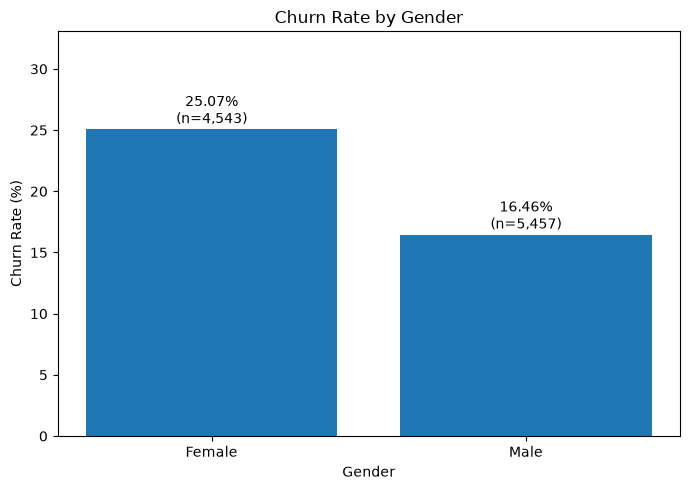

In [21]:
# Plot churn rate by gender
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    gender_churn.index,
    gender_churn["churn_rate"]
)

ax.set_title("Churn Rate by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, gender_churn["churn_rate"].max() + 8)

for bar, (_, row) in zip(bars, gender_churn.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{row["churn_rate"]:.2f}%\n(n={int(row["customers"]):,})',
        ha="center"
    )

plt.tight_layout()
plt.show()

In [22]:
# Customer characteristics by country
country_profile = (
    df.groupby("country")
      .agg(
          customers=("customer_id", "count"),
          churn_rate=("churn", "mean"),
          mean_age=("age", "mean"),
          mean_balance=("balance", "mean"),
          mean_products=("products_number", "mean"),
          active_rate=("active_member", "mean")
      )
)

country_profile["churn_rate"] *= 100
country_profile["active_rate"] *= 100

country_profile.round(2)

,customers,churn_rate,mean_age,mean_balance,mean_products,active_rate
country,,,,,,
France,5014,16.15,38.51,62092.64,1.53,51.68
Germany,2509,32.44,39.77,119730.12,1.52,49.74
Spain,2477,16.67,38.89,61818.15,1.54,52.97


#### Key findings

Churn rates varied considerably by country. Customers in Germany had the highest churn rate at 32.44%, compared with 16.15% in France and 16.67% in Spain. German customers also had a substantially higher mean account balance, at approximately 119,730 compared with approximately 62,093 in France and 61,818 in Spain. Average age, product ownership and active membership were relatively similar across the three countries. These results indicate that country may provide useful information for churn prediction, although the descriptive analysis does not establish the reasons for the higher churn rate among German customers.

Gender also showed a difference in churn behaviour. Female customers had a churn rate of 25.07%, compared with 16.46% among male customers. Gender will therefore be retained as a potential predictor for the churn modelling stage, where its contribution can be assessed alongside the other customer characteristics.

### 6.2.8 Remaining Churn Predictors

Credit score, tenure, estimated salary and credit-card ownership are also examined as potential predictors of customer churn. These variables are assessed together to determine whether they show meaningful differences between churners and non-churners.

In [23]:
# Summary of remaining numerical variables by churn status
remaining_numerical = (
    df.groupby("churn")[
        ["credit_score", "tenure", "estimated_salary"]
    ]
    .agg(["mean", "median", "std"])
    .round(2)
)

remaining_numerical

credit_score                tenure              estimated_salary  \
              mean median     std   mean median   std             mean   
churn                                                                    
0           651.85  653.0   95.65   5.03    5.0  2.88         99738.39   
1           645.35  646.0  100.32   4.93    5.0  2.94        101465.68   

                            
          median       std  
churn                       
0       99645.04  57405.59  
1      102460.84  57912.42

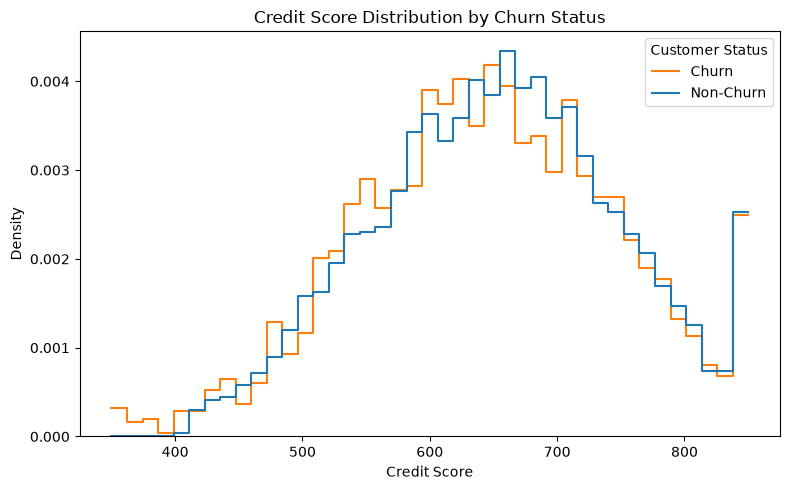

In [24]:
# Credit score distribution by churn status
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="credit_score",
    hue="churn",
    stat="density",
    common_norm=False,
    element="step",
    fill=False
)

plt.title("Credit Score Distribution by Churn Status")
plt.xlabel("Credit Score")
plt.ylabel("Density")

plt.legend(
    title="Customer Status",
    labels=["Churn", "Non-Churn"]
)

plt.tight_layout()
plt.show()

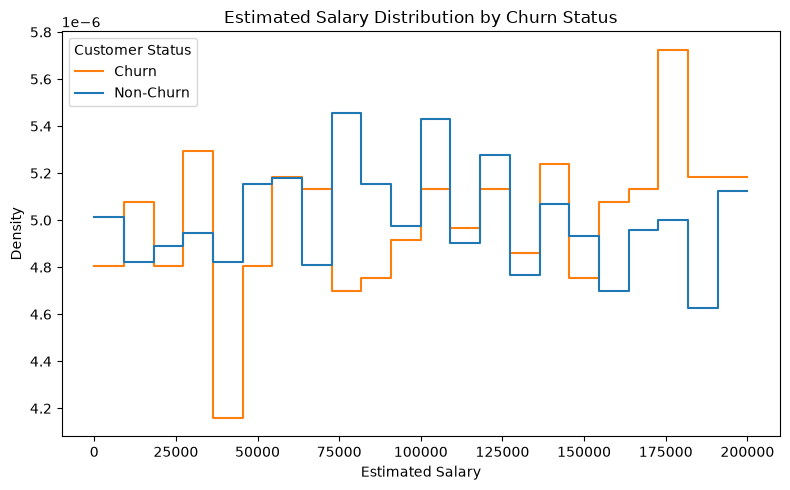

In [25]:
# Estimated salary distribution by churn status
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="estimated_salary",
    hue="churn",
    stat="density",
    common_norm=False,
    element="step",
    fill=False
)

plt.title("Estimated Salary Distribution by Churn Status")
plt.xlabel("Estimated Salary")
plt.ylabel("Density")

plt.legend(
    title="Customer Status",
    labels=["Churn", "Non-Churn"]
)

plt.tight_layout()
plt.show()

In [26]:
# Churn rate by tenure
tenure_churn = (
    df.groupby("tenure")["churn"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "customers",
          "sum": "churners",
          "mean": "churn_rate"
      })
)

tenure_churn["churn_rate"] *= 100

tenure_churn.round(2)

,customers,churners,churn_rate
tenure,,,
0,413,95,23.00
1,1035,232,22.42
2,1048,201,19.18
3,1009,213,21.11
4,989,203,20.53
5,1012,209,20.65
6,967,196,20.27
7,1028,177,17.22
8,1025,197,19.22


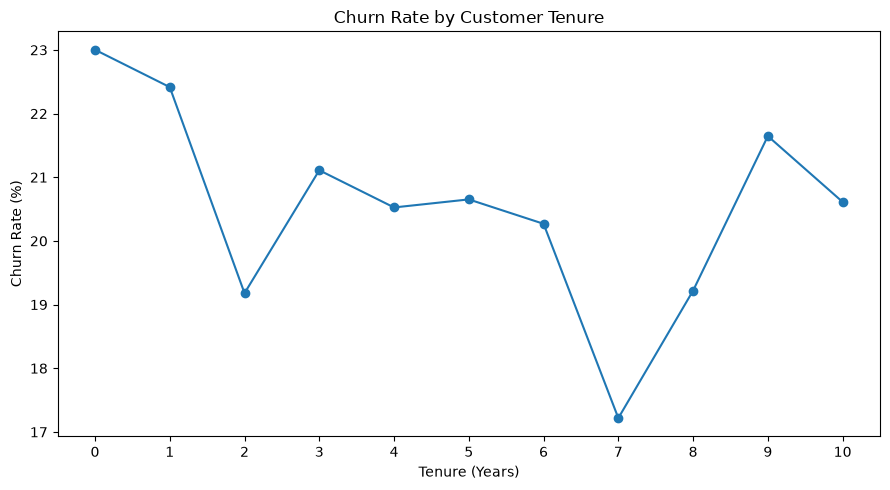

In [27]:
# Plot churn rate by tenure
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    tenure_churn.index,
    tenure_churn["churn_rate"],
    marker="o"
)

ax.set_title("Churn Rate by Customer Tenure")
ax.set_xlabel("Tenure (Years)")
ax.set_ylabel("Churn Rate (%)")
ax.set_xticks(tenure_churn.index)

plt.tight_layout()
plt.show()

In [28]:
# Churn by credit-card ownership
credit_card_churn = (
    df.groupby("credit_card")["churn"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "customers",
          "sum": "churners",
          "mean": "churn_rate"
      })
)

credit_card_churn["churn_rate"] *= 100

credit_card_churn.index = credit_card_churn.index.map({
    0: "No Credit Card",
    1: "Credit Card"
})

credit_card_churn.round(2)

,customers,churners,churn_rate
credit_card,,,
No Credit Card,2945,613,20.81
Credit Card,7055,1424,20.18


#### Key findings

Credit score showed only a small difference between churners and non-churners, with mean scores of 645.35 and 651.85 respectively. The substantial overlap between the distributions suggests that credit score has a relatively weak standalone relationship with churn.

Estimated salary also showed little separation between the two groups. Churners had a slightly higher mean estimated salary (£101,465.68) than non-churners (£99,738.39), but the distributions were broadly similar.

Customer tenure did not demonstrate a clear linear relationship with churn. Churn rates varied across tenure levels, ranging from 17.22% at seven years to 23.00% among customers with zero years of tenure, while mean tenure was similar for churners and non-churners. These variables will therefore be retained as potential predictors, as weak individual relationships do not rule out predictive value when considered alongside other customer characteristics.

Credit-card ownership showed very little difference in churn behaviour. Customers without a credit card had a churn rate of 20.81%, compared with 20.18% among customers with a credit card. This suggests that credit-card ownership has a weak standalone relationship with customer churn, although the variable will be retained for the modelling stage to determine whether it contributes predictive information when considered alongside other customer characteristics.